# Performance comparison
Here we walk through the necessary steps to reproduce the main figures of the performance comparison of different RBP datasets across cell lines using BRIDGE.

## 1. Load BRIDGE model and compute metrics
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the BRIDGE metrics.

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/validate_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running validate for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --validate \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 1 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running validate for: AARS_K562
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15000 sequences for AARS_K562, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/output/AARS_K562/output/STRME_training_set.tab
AARS_K562 auc: 0.7972 acc: 0.7737 auprc: 0.7224 mcc: 0.4605
Running validat

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
LOG="results/logs/validate_all.log"
OUT="results/benchmarks/BRIDGE_auc.tsv"
mkdir -p results/benchmarks

echo -e "RBP_Cell\tBRIDGE" > "$OUT"

grep -E '^[A-Za-z0-9]+_[A-Za-z0-9]+ auc:' "$LOG" \
  | awk '{print $1 "\t" $3}' \
  >> "$OUT" || true

echo "Wrote: $OUT"
cat "$OUT"

Wrote: results/benchmarks/BRIDGE_auc.tsv
RBP_Cell	BRIDGE
AUH_K562	0.9265
AARS_K562	0.7972
AUH_HepG2	0.8979
AUH_K562	0.9265


## 2. Downstream analysis of cell type-specific BRIDGE results
Here we walk through the necessary steps to analyze BRIDGE baseline performance across RBP domain and functional categories.

#### Load precomputed results for BRIDGE and other methods
```{note}
Running BRIDGE on the full dataset can take a long time. For convenience, we also provide the precomputed results for BRIDGE and all baseline methods on Figshare, as `{metrics}_baselines.metrics`, which you can download directly.

You can modify `project_root` below to change where the data is stored.
```

In [1]:
import os
import pandas as pd

# -----------------------------
# Paths (edit if needed)
# -----------------------------
project_root = "/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility"
annotation_dir = os.path.join(project_root, "motif_construction", "RBP_annotation_data")
metrics_dir = os.path.join(project_root, "results", "metrics")

# Metric files to process
metric_files = {
    "AUC":   os.path.join(metrics_dir, "AUC_baselines.metrics"),
    "ACC":   os.path.join(metrics_dir, "ACC_baselines.metrics"),
    "AUPRC": os.path.join(metrics_dir, "AUPRC_baselines.metrics"),
    "MCC":   os.path.join(metrics_dir, "MCC_baselines.metrics"),
}

# -----------------------------
# Domain / function category lists
# -----------------------------
domain_files = {
    "dsRBD": "DSrbp_list.txt",
    "Helicase": "Helicase_list.txt",
    "KH": "KHrbp_list.txt",
    "RRM": "RRMrbp_list.txt",
    "ZincFinger": "ZNFrbp_list.txt",
}

function_files = {
    "splice": "splicerbp_list.txt",
    "stability": "stabilityrbp_list.txt",
    "translation": "translationrbp_list.txt",
}

def load_rbp_list(filepath: str) -> set:
    """Load RBP_Cell names from a text file (one name per line)."""
    with open(filepath, "r") as f:
        return {line.strip() for line in f if line.strip()}

domain_dict = {k: load_rbp_list(os.path.join(annotation_dir, v)) for k, v in domain_files.items()}
function_dict = {k: load_rbp_list(os.path.join(annotation_dir, v)) for k, v in function_files.items()}

# -----------------------------
# Helper: read *.metrics
# -----------------------------
def read_metrics_file(path: str) -> pd.DataFrame:
    """
    Read a baseline metrics file and return a dataframe.

    - It is tab- or whitespace-delimited
    - First column is the RBP_Cell identifier (or similar key)
    - Other columns are model names (e.g., BRIDGE, HDRNet, ...)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Metrics file not found: {path}")

    # Try tab-separated first; if it results in 1 column, fall back to whitespace.
    df = pd.read_csv(path, sep="\t", engine="python")
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep=r"\s+", engine="python")

    # Normalize first column as RBP_Cell
    first_col = df.columns[0]
    if first_col != "RBP_Cell":
        df = df.rename(columns={first_col: "RBP_Cell"})

    # Drop missing keys and set index
    df = df.dropna(subset=["RBP_Cell"]).set_index("RBP_Cell")
    return df

# -----------------------------
# Main loop
# -----------------------------
target_method = "BRIDGE"

for metric_name, metric_path in metric_files.items():
    df = read_metrics_file(metric_path)

    if target_method not in df.columns:
        raise KeyError(
            f"Column '{target_method}' not found in {metric_path}. "
            f"Available columns: {list(df.columns)}"
        )

    # Collect values by category
    domain_values = {k: [] for k in domain_dict}
    function_values = {k: [] for k in function_dict}

    for rbp_cell, row in df.iterrows():
        value = row[target_method]

        for domain, rbps in domain_dict.items():
            if rbp_cell in rbps:
                domain_values[domain].append(value)

        for func, rbps in function_dict.items():
            if rbp_cell in rbps:
                function_values[func].append(value)

    # Save as CSV (columns can have different lengths)
    df_domain_out = pd.DataFrame({k: pd.Series(v) for k, v in domain_values.items()})
    df_func_out = pd.DataFrame({k: pd.Series(v) for k, v in function_values.items()})

    out_domain = f"RBP_domain_{metric_name}.csv"
    out_func = f"RBP_function_{metric_name}.csv"

    df_domain_out.to_csv(out_domain, index=False)
    df_func_out.to_csv(out_func, index=False)

    print(f"[Saved] {metric_name}: {out_domain} and {out_func}")


[Saved] AUC: RBP_domain_AUC.csv and RBP_function_AUC.csv
[Saved] ACC: RBP_domain_ACC.csv and RBP_function_ACC.csv
[Saved] AUPRC: RBP_domain_AUPRC.csv and RBP_function_AUPRC.csv
[Saved] MCC: RBP_domain_MCC.csv and RBP_function_MCC.csv


### The plotting function

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


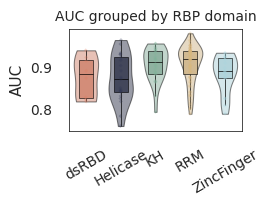

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


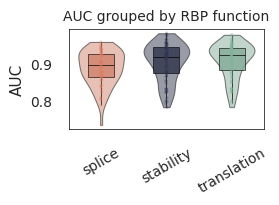

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


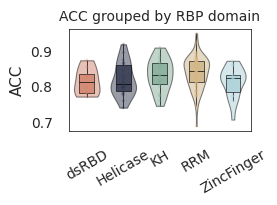

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


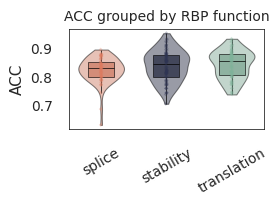

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


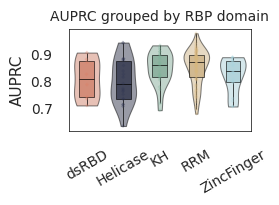

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


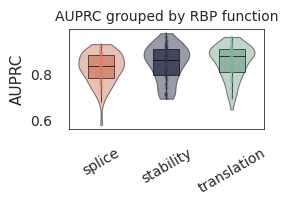

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


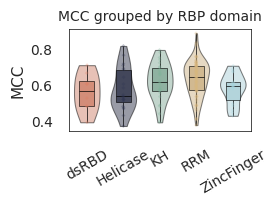

/tmp/ipykernel_779037/713521507.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_779037/713521507.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_779037/713521507.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


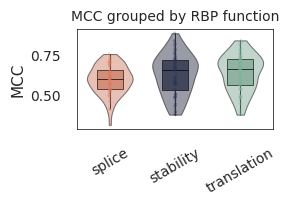

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 1) Paths
# =============================
# Directory that contains the 8 CSV files:
#   RBP_domain_AUC.csv, RBP_domain_ACC.csv, RBP_domain_AUPRC.csv, RBP_domain_MCC.csv
#   RBP_function_AUC.csv, RBP_function_ACC.csv, RBP_function_AUPRC.csv, RBP_function_MCC.csv
CSV_DIR = Path(".")  # change this if your CSVs are elsewhere

# Optional: output directory (only used if SAVE=True)
OUT_DIR = Path("./results/figures/rbp_group_violins")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set SAVE=False to only show figures in the notebook
SAVE = False

# =============================
# 2) Style (reuse your fig2d look)
# =============================
# Figure size in centimeters -> inches (same style as your fig2d)
FIG_W_CM, FIG_H_CM = 7.0, 5.25
FIG_W, FIG_H = FIG_W_CM / 2.54, FIG_H_CM / 2.54

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
sns.set_style("white")  # no grid background

# Base palette (reuse your fig2d palette idea; colors will be assigned in column order)
BASE_PALETTE = [
    "#E07B5F",  # coral
    "#2F3553",  # dark blue
    "#7FB39A",  # green
    "#D9B77E",  # sand
    "#A6D6E0",  # cyan
    "#8F92C8",  # lavender
    "#E58A8A",  # pink/red
    "#b68b6c",  # brown
]

def plot_violin_from_category_csv(csv_path: Path, metric_name: str, group_name: str):
    """
    Plot violin/box/points with your fig2d styling.
    Input CSV is in wide format:
      - Each column is a category (domain/function type)
      - Each column contains values (columns can have different lengths; NaNs are allowed)
    """
    if not csv_path.exists():
        print(f"[Skip] Missing file: {csv_path}")
        return

    df_wide = pd.read_csv(csv_path)
    categories = list(df_wide.columns)  # preserve original column order

    # Convert wide -> long
    df_long = df_wide.melt(var_name="Category", value_name="Value").dropna(subset=["Value"])
    if df_long.empty:
        print(f"[Skip] No valid values in: {csv_path}")
        return

    # Assign colors to categories in order
    palette = {cat: BASE_PALETTE[i % len(BASE_PALETTE)] for i, cat in enumerate(categories)}

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    # Violin layer (semi-transparent with black edges)
    sns.violinplot(
        data=df_long, x="Category", y="Value",
        order=categories,
        palette=palette,
        cut=0,
        inner=None,
        width=0.7,
        linewidth=0.75,
        ax=ax
    )
    for coll in ax.collections:
        try:
            coll.set_alpha(0.5)
            coll.set_edgecolor("black")
            coll.set_linewidth(0.75)
        except Exception:
            pass

    # Box layer (overlay)
    sns.boxplot(
        data=df_long, x="Category", y="Value",
        order=categories,
        palette=palette,
        width=0.4,
        showfliers=False,
        showcaps=False,
        boxprops={"edgecolor": "black", "linewidth": 0.50, "alpha": 0.85},
        whiskerprops={"color": "black", "linewidth": 0.50},
        capprops={"color": "black", "linewidth": 0.50},
        medianprops={"color": "black", "linewidth": 0.50},
        ax=ax
    )

    # Point layer (diamond markers)
    sns.stripplot(
        data=df_long, x="Category", y="Value",
        order=categories,
        palette=palette,
        jitter=0.01,
        size=2.0,
        alpha=0.3,
        marker="D",
        linewidth=0,
        ax=ax
    )

    # Axis formatting (no grid, thin spines, rotated x labels)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} grouped by RBP {group_name}", fontsize=10)

    ax.tick_params(axis="x", rotation=30)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")

    ax.tick_params(axis="both", width=0.5, length=8, direction="out", color="black")
    ax.grid(False)

    # Set a tight y-range with small padding
    y_min, y_max = df_long["Value"].min(), df_long["Value"].max()
    y_rng = (y_max - y_min) if (y_max > y_min) else 1.0
    ax.set_ylim(y_min - 0.05 * y_rng, y_max + 0.05 * y_rng)

    # Remove legend if any
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    fig.tight_layout()

    # Show or save
    if SAVE:
        out_path = OUT_DIR / f"violin_RBP_{group_name}_{metric_name}.pdf"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"[Saved] {out_path}")
        plt.close(fig)
    else:
        plt.show()

# =============================
# 3) Plot 8 figures: (domain/function) x (AUC/ACC/AUPRC/MCC)
# =============================
metrics = ["AUC", "ACC", "AUPRC", "MCC"]

for metric in metrics:
    plot_violin_from_category_csv(
        csv_path=CSV_DIR / f"RBP_domain_{metric}.csv",
        metric_name=metric,
        group_name="domain"
    )
    plot_violin_from_category_csv(
        csv_path=CSV_DIR / f"RBP_function_{metric}.csv",
        metric_name=metric,
        group_name="function"
    )
